In [1]:
%load_ext autoreload
%autoreload 2

import mteb
from itertools import product
from utils.dataloaders.text_dataloader import load_dataset
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from utils.model_definitions.text_automodel_wrapper import TextModelSpecifications, TextLayerwiseAutoModelWrapper
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)
from utils.metrics.metric_functions import compute_entropy
import torch
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from transformers.utils import logging
logging.set_verbosity_error()

# Text Task

### Load Model and Dataset

In [6]:
model_specs = TextModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)

In [ ]:
model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")

In [60]:
dataset = load_dataset("mteb/amazon_massive_intent", trust_remote_code=True)

dataset = dataset.filter(lambda x: x['lang'] == 'en')
dataset = dataset.filter(lambda x: len(x['text'].split()) > 1) # filter out prompts that are only one word

train_split = dataset['train']
test_split = dataset['test']

Using the latest cached version of the dataset since mteb/amazon_massive_intent couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/AD/ofsk222/.cache/huggingface/datasets/mteb___amazon_massive_intent/default/0.0.0/4672e20407010da34463acc759c162ca9734bca6 (last modified on Sun Jan 19 17:00:21 2025).


Filter:   0%|          | 0/11514 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2974 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2033 [00:00<?, ? examples/s]

In [61]:
cursplit = train_split

# number of classes
num_classes = len(set(cursplit["label"]))
print(f"Number of classes: {num_classes}")

# number of samples per class
samples_per_class = {}
labels = np.array(cursplit["label"])
for i in set(labels):
    samples_per_class[i] = np.sum(labels == i)

# number of samples
num_samples = len(labels)
print(f"Number of samples: {num_samples}")

# print in descending order of the values
print("Samples per class:")
for i in sorted(samples_per_class, key=samples_per_class.get, reverse=True):
    print(f"\t{i}: {samples_per_class[i]}")

Number of classes: 60
Number of samples: 11384
Samples per class:
	calendar_set: 801
	play_music: 632
	weather_query: 568
	calendar_query: 563
	qa_factoid: 543
	general_quirky: 526
	news_query: 496
	email_query: 417
	email_sendemail: 354
	datetime_query: 348
	calendar_remove: 309
	social_post: 282
	play_radio: 281
	qa_definition: 260
	transport_query: 225
	cooking_recipe: 203
	lists_query: 197
	play_podcasts: 190
	recommendation_events: 188
	alarm_set: 181
	lists_createoradd: 176
	recommendation_locations: 173
	lists_remove: 163
	music_query: 153
	iot_hue_lightoff: 152
	qa_stock: 151
	play_audiobook: 149
	qa_currency: 142
	takeaway_order: 134
	alarm_query: 129
	transport_ticket: 127
	email_querycontact: 126
	iot_hue_lightchange: 124
	iot_coffee: 124
	takeaway_query: 122
	transport_traffic: 113
	music_likeness: 111
	play_game: 110
	social_query: 106
	audio_volume_mute: 105
	audio_volume_up: 105
	transport_taxi: 99
	iot_cleaning: 93
	alarm_remove: 77
	iot_hue_lightup: 76
	qa_maths: 76
	i

### Text Entropy Functions

In [93]:
def calculate_entropy(encodings):
    encodings = encodings / np.linalg.norm(encodings, axis=1, keepdims=True)
    encodings = torch.tensor(encodings)
    if len(encodings.shape) == 2:
        encodings = encodings.unsqueeze(0)

    entropy = compute_entropy(encodings)

    if len(entropy['maxEntropy']) == 1:
        return entropy['maxEntropy'][0]
    else:
        return entropy['maxEntropy']

def calculate_average_layerwise_prompt_entropies(sample_hidden_states):
    layerwise_entropies = []
    for sample in tqdm.tqdm(sample_hidden_states, disable=True):
        entropies = calculate_entropy(sample)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)

    return layerwise_entropies.mean(axis=0)

def calculate_layerwise_dataset_entropies(layerwise_encodings):
    layerwise_entropies = []
    for layer in tqdm.tqdm(layerwise_encodings, disable=True):
        entropies = calculate_entropy(layer)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)
    return layerwise_entropies


### Test Calculations

In [86]:
train_split = dataset['train']
x_train, y_train = train_split['text'], train_split['label']
test_split = dataset['test']
x_test, y_test = test_split['text'], test_split['label']

classes = np.random.choice(y_train, size=10, replace=False)
print(classes)

# narrow down to the classes
mask = np.isin(y_train, classes)
x_train = list(np.array(x_train)[mask])
y_train = list(np.array(y_train)[mask])

mask = np.isin(y_test, classes)
x_test = list(np.array(x_test)[mask])
y_test = list(np.array(y_test)[mask])

kwargs = {
    "verbose": False
}
encoded_train, raw_hidden_states_train, layerwise_encodings_train = model.encode(x_train, return_raw_hidden_states=True, **kwargs)
encoded_test, raw_hidden_states_test, layerwise_encodings_test = model.encode(x_test, return_raw_hidden_states=True, **kwargs)

a = calculate_average_layerwise_prompt_entropies(raw_hidden_states_train)
b = calculate_layerwise_dataset_entropies(layerwise_encodings_train)

cooking_query ['weather_query' 'iot_hue_lightchange' 'recommendation_events'
 'recommendation_events' 'transport_ticket' 'recommendation_events'
 'play_music' 'general_quirky' 'qa_factoid' 'cooking_recipe']


100%|█████████▉| 2907/2911 [00:12<00:00, 222.56it/s]/tmp/ipykernel_4148693/74380111.py:2: RuntimeWarning: invalid value encountered in divide
  encodings = encodings / np.linalg.norm(encodings, axis=1, keepdims=True)
100%|██████████| 25/25 [00:10<00:00,  2.43it/s]


## Main Experiments

In [4]:
import os
import pickle

def save_results(results, seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def check_if_results_exist(seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    return os.path.exists(path)


In [108]:
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler

def process_layer(x_train, x_test, y_train, y_test):
    normalized_X_train = StandardScaler().fit_transform(x_train) 
    normalized_X_test = StandardScaler().fit_transform(x_test)

    clf = LogisticRegression(
        n_jobs=2,
        max_iter=250
    )
    clf.fit(normalized_X_train, y_train)
    y_pred = clf.predict(normalized_X_test)
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro')
    }

In [111]:

# adapted from https://github.com/embeddings-benchmark/mteb/blob/762f729b70cdad2e9137a68af4b2693ca96dd3b7/mteb/abstasks/AbsTaskClassification.py#L132

NUM_CLASSES = 4
NUM_EXPERIMENTS = 100
SEED_START = 0

RESULTS = []

for i in range(NUM_EXPERIMENTS):
    torch.manual_seed(SEED_START + i)
    np.random.seed(SEED_START + i)

    if check_if_results_exist(SEED_START + i, NUM_CLASSES):
        print(f"Results for seed {SEED_START + i} and {NUM_CLASSES} classes already exist")
        continue

    train_split = dataset['train']
    x_train, y_train = train_split['text'], train_split['label']
    test_split = dataset['test']
    x_test, y_test = test_split['text'], test_split['label']

    # choose NUM_CLASSES classes
    class_choices = np.unique(y_train)
    classes = np.random.choice(class_choices, size=NUM_CLASSES, replace=False)
    print(i, classes)

    # narrow down to the classes
    mask = np.isin(y_train, classes)
    x_train = list(np.array(x_train)[mask])
    y_train = list(np.array(y_train)[mask])

    mask = np.isin(y_test, classes)
    x_test = list(np.array(x_test)[mask])
    y_test = list(np.array(y_test)[mask])

    kwargs = {
        "verbose": False
    }
    encoded_train, raw_hidden_states_train, layerwise_encodings_train = model.encode(x_train, return_raw_hidden_states=True, **kwargs)
    encoded_test, raw_hidden_states_test, layerwise_encodings_test = model.encode(x_test, return_raw_hidden_states=True, **kwargs)

    # Process all layers in parallel
    results = Parallel(n_jobs=-1)(
        delayed(process_layer)(layerwise_encodings_train[idx], layerwise_encodings_test[idx], y_train, y_test) 
        for idx in range(len(layerwise_encodings_train))
    )
    layerwise_accuracies = [r['accuracy'] for r in results]
    layerwise_f1_scores = [r['f1'] for r in results]
    layerwise_precisions = [r['precision'] for r in results]
    layerwise_recalls = [r['recall'] for r in results]


    experiment_results = {
        "accuracy": layerwise_accuracies,
        "f1_score": layerwise_f1_scores,
        "precision": layerwise_precisions,
        "recall": layerwise_recalls,
        "seed": SEED_START + i,
        "num_classes": NUM_CLASSES,
        "num_samples": len(y_test),
        "num_samples_per_class": samples_per_class,
        "classes": classes,
        'prompt_entropy': calculate_average_layerwise_prompt_entropies(raw_hidden_states_test),
        'dataset_entropy': calculate_layerwise_dataset_entropies(layerwise_encodings_test)
    }

    RESULTS.append(experiment_results)
    save_results(experiment_results, SEED_START + i, NUM_CLASSES)

0 ['iot_hue_lighton' 'music_query' 'weather_query' 'iot_wemo_off'
 'cooking_recipe' 'alarm_set' 'music_likeness' 'transport_traffic'
 'play_music' 'iot_coffee']


## Load Results

In [7]:
CLASSNUM_LIST = [8, 16, 32]

CLASSNUM_TO_RESULTS = {}
for classnum in CLASSNUM_LIST:
    classnum_results = []
    for i in range(100):
        if check_if_results_exist(i, classnum):
            with open(f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/CLASSES_{classnum}/SEED_{i}.pkl", "rb") as f:
                classnum_results.append(pickle.load(f))
    CLASSNUM_TO_RESULTS[classnum] = classnum_results


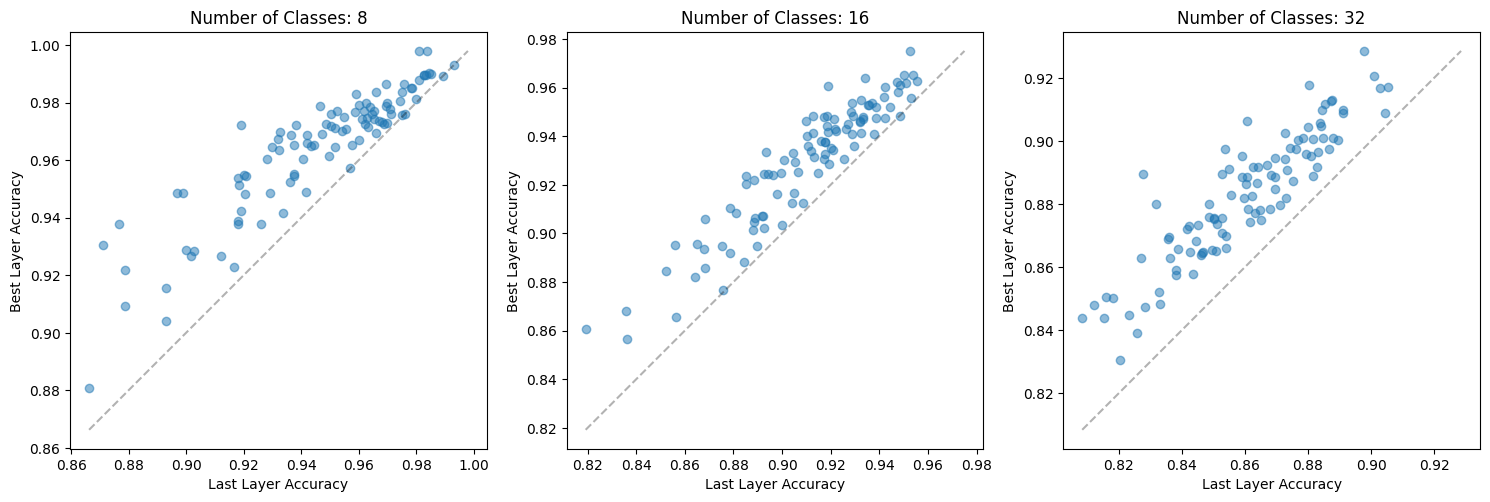

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

for idx, classnum in enumerate(CLASSNUM_LIST):
    plt.subplot(1, 3, idx+1)
    
    results = CLASSNUM_TO_RESULTS[classnum]
    
    best_layer_accs = []
    last_layer_accs = []
    
    for result in results:
        accuracies = result['f1_score']
        best_layer_accs.append(max(accuracies))
        last_layer_accs.append(accuracies[-1])
    
    plt.scatter(last_layer_accs, best_layer_accs, alpha=0.5)
    
    # Add diagonal line
    min_val = min(min(best_layer_accs), min(last_layer_accs))
    max_val = max(max(best_layer_accs), max(last_layer_accs))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3)
    
    plt.xlabel('Last Layer Accuracy')
    plt.ylabel('Best Layer Accuracy')
    plt.title(f'Number of Classes: {classnum}')
    
    # Make axes equal
    plt.axis('square')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

for idx, classnum in enumerate(CLASSNUM_LIST):
    plt.subplot(1, 3, idx+1)
    
    results = CLASSNUM_TO_RESULTS[classnum]
    
    best_layer_entropies = []
    last_layer_entropies = []
    
    for result in results:
        entropies = result['prompt_entropy']
        best_layer_idx = np.argmax(result['f1_score'])
        best_layer_entropies.append(entropies[best_layer_idx])
        last_layer_entropies.append(entropies[-1])

        if best_layer_entropies[-1] >= last_layer_entropies[-1]:
            print(result['seed'])
            print("Best Layer Accuracy: ", result['f1_score'][best_layer_idx], "Last Layer Accuracy: ", result['f1_score'][-1])
            print("Best Layer Entropy: ", entropies[best_layer_idx], "Last Layer Entropy: ", entropies[-1])
    
    plt.scatter(last_layer_entropies, best_layer_entropies, alpha=0.5)
    
    # Add diagonal line
    min_val = min(min(best_layer_entropies), min(last_layer_entropies))
    max_val = max(max(best_layer_entropies), max(last_layer_entropies))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3)
    
    plt.xlabel('Last Layer Entropy')
    plt.ylabel('Best Layer Entropy')
    plt.title(f'Number of Classes: {classnum}')
    
    # Make axes equal
    plt.axis('square')

plt.tight_layout()
plt.show()

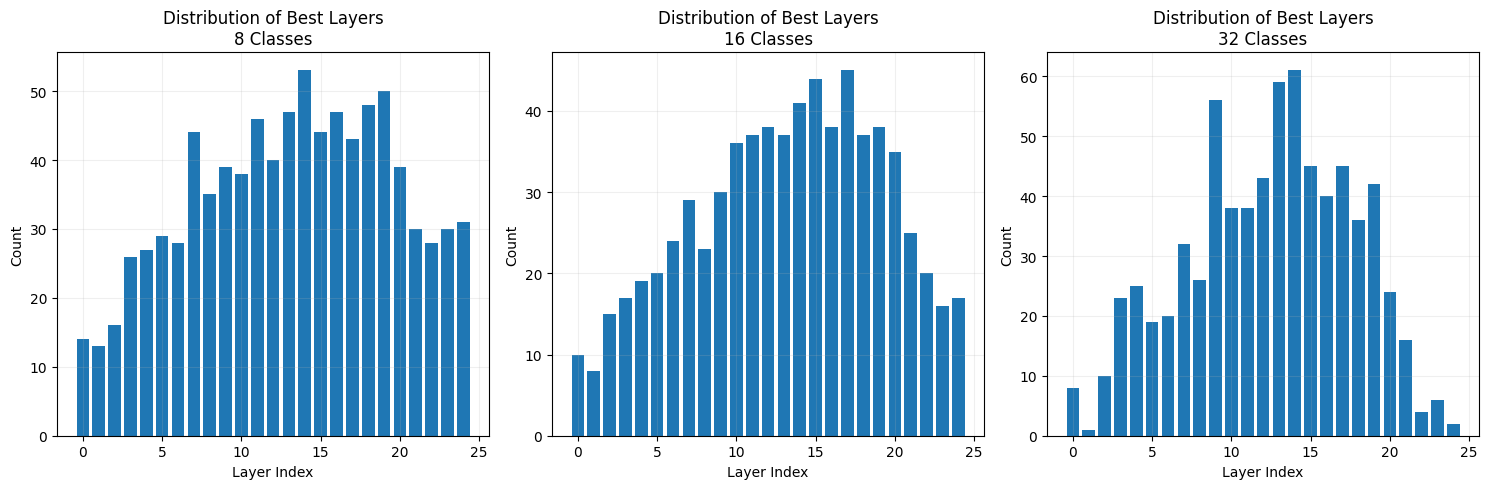

In [23]:
plt.figure(figsize=(15, 5))

for idx, classnum in enumerate([8, 16, 32]):
    plt.subplot(1, 3, idx+1)
    
    best_layers = []
    results = CLASSNUM_TO_RESULTS[classnum]
    
    for result in results:
        accuracies = result['f1_score']
        best_acc = np.max(accuracies)
        threshold = best_acc - (best_acc * 0.01)  # within 0.5%
        best_layer_indices = np.where(accuracies >= threshold)[0]
        best_layers.extend(best_layer_indices)

    plt.hist(best_layers, bins=range(min(best_layers), max(best_layers) + 2, 1),
             align='left', rwidth=0.8)
    plt.xlabel('Layer Index')
    plt.ylabel('Count')
    plt.title(f'Distribution of Best Layers\n{classnum} Classes')
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# Vision Task

## Load Model and Dataset

In [2]:
from utils.model_definitions.vision_automodel_wrapper import VisionLayerwiseAutoModelWrapper, VisionModelSpecifications
from utils.dataloaders.vision_dataloader import prepare_datasets, prepare_dataloader, validation_imagenet_transform, simclr_imagenet_transform

In [3]:
model_specs = VisionModelSpecifications(
    model_family="dinov2", 
    model_size="base", 
    revision="main")
model = VisionLayerwiseAutoModelWrapper(model_specs, device_map="auto")

In [4]:
image_transform = validation_imagenet_transform()

validation_imagenet_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/train",
    number_of_samples=-1
)

validation_dataloader = prepare_dataloader(validation_imagenet_dataset, batch_size=32, num_workers=16, shuffle=True)


## Test Class Subsampling

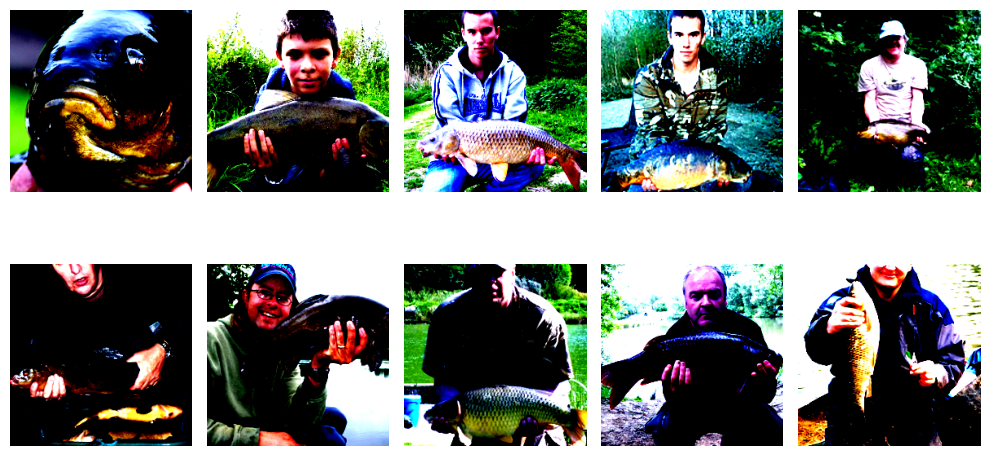

In [5]:
import matplotlib.pyplot as plt
desired_classes = [0]

# filter the dataset to only include the desired classes
indices = [i for i, x in enumerate(validation_imagenet_dataset.targets) if x in desired_classes]

# create a new dataset with the filtered indices
filtered_dataset = torch.utils.data.Subset(validation_imagenet_dataset, indices)

filtered_dataloader = prepare_dataloader(filtered_dataset, batch_size=32, num_workers=16, shuffle=True)

for batch in filtered_dataloader:
    # Get 4 random indices from the batch
    batch_size = len(batch[1])
    random_indices = np.random.choice(batch_size, 10, replace=False)
    images = [batch[1][i] for i in random_indices]
    break

# Create a 5x2 subplot
fig, axes = plt.subplots(2, 5, figsize=(10, 6))

for idx, image in enumerate(images):
    # Convert to numpy and reshape
    img = image.cpu().numpy().reshape(3, 224, 224)
    img = np.transpose(img, (1, 2, 0))
    
    # Plot in the corresponding subplot
    row = idx // 5
    col = idx % 5
    axes[row, col].imshow(img)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Main Experiments

In [6]:
import os
import pickle

def save_results(results, seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def check_if_results_exist(seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    return os.path.exists(path)


In [11]:
def calculate_entropy(encodings):
    encodings = encodings / np.linalg.norm(encodings, axis=1, keepdims=True)
    encodings = torch.tensor(encodings)
    if len(encodings.shape) == 2:
        encodings = encodings.unsqueeze(0)

    entropy = compute_entropy(encodings)

    if len(entropy['maxEntropy']) == 1:
        return entropy['maxEntropy'][0]
    else:
        return entropy['maxEntropy']

def calculate_average_layerwise_prompt_entropies(sample_hidden_states):
    layerwise_entropies = []
    for sample in tqdm.tqdm(sample_hidden_states, disable=True):
        entropies = calculate_entropy(sample)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)

    return layerwise_entropies.mean(axis=0)

def calculate_layerwise_dataset_entropies(layerwise_encodings):
    layerwise_entropies = []
    for layer in tqdm.tqdm(layerwise_encodings, disable=True):
        entropies = calculate_entropy(layer)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)
    return layerwise_entropies

In [7]:
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler

def process_layer(x_train, x_test, y_train, y_test):
    normalized_X_train = StandardScaler().fit_transform(x_train) 
    normalized_X_test = StandardScaler().fit_transform(x_test)

    clf = LogisticRegression(
        n_jobs=2,
        max_iter=250
    )
    clf.fit(normalized_X_train, y_train)
    y_pred = clf.predict(normalized_X_test)
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro')
    }

def filter_dataset(dataset, classes):
    indices = [i for i, x in enumerate(dataset.targets) if x in classes]
    return torch.utils.data.Subset(dataset, indices)

In [33]:
# adapted from https://github.com/embeddings-benchmark/mteb/blob/762f729b70cdad2e9137a68af4b2693ca96dd3b7/mteb/abstasks/AbsTaskClassification.py#L132
NUM_CLASSES = 32
NUM_EXPERIMENTS = 1
SEED_START = 0

RESULTS = []

image_transform = validation_imagenet_transform()

full_imagenet_train_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/train",
    number_of_samples=-1
)
full_imagenet_val_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/val_sorted",
    number_of_samples=-1
)

for i in range(NUM_EXPERIMENTS):
    torch.manual_seed(SEED_START + i)
    np.random.seed(SEED_START + i)

    if check_if_results_exist(SEED_START + i, NUM_CLASSES):
        print(f"Results for seed {SEED_START + i} and {NUM_CLASSES} classes already exist")
        continue

    chosen_classes = np.random.choice(np.unique(full_imagenet_train_dataset.targets), size=NUM_CLASSES, replace=False)
    train_dataset = filter_dataset(full_imagenet_train_dataset, chosen_classes)
    test_dataset = filter_dataset(full_imagenet_val_dataset, chosen_classes)

    kwargs = {
        "verbose": True
    }
    encoded_train, raw_hidden_states_train, layerwise_encodings_train, y_train = model.encode(train_dataset, return_raw_hidden_states=True, **kwargs)
    encoded_test, raw_hidden_states_test, layerwise_encodings_test, y_test = model.encode(test_dataset, return_raw_hidden_states=True, **kwargs)

    # Process all layers in parallel
    results = Parallel(n_jobs=-1)(
        delayed(process_layer)(layerwise_encodings_train[idx], layerwise_encodings_test[idx], y_train, y_test) 
        for idx in range(len(layerwise_encodings_train))
    )
    layerwise_accuracies = [r['accuracy'] for r in results]
    layerwise_f1_scores = [r['f1'] for r in results]
    layerwise_precisions = [r['precision'] for r in results]
    layerwise_recalls = [r['recall'] for r in results]


    experiment_results = {
        "accuracy": layerwise_accuracies,
        "f1_score": layerwise_f1_scores,
        "precision": layerwise_precisions,
        "recall": layerwise_recalls,
        "seed": SEED_START + i,
        "num_classes": NUM_CLASSES,
        "num_samples": len(y_test),
        "classes": chosen_classes,
        'prompt_entropy': calculate_average_layerwise_prompt_entropies(raw_hidden_states_test),
        'dataset_entropy': calculate_layerwise_dataset_entropies(layerwise_encodings_test)
    }

    RESULTS.append(experiment_results)
    save_results(experiment_results, SEED_START + i, NUM_CLASSES)

 65%|██████▌   | 52/80 [05:17<04:33,  9.76s/it]

: 

In [ ]:
print(RESULTS[0]['f1_score'])

In [ ]:
# plot the prompt entropy
plt.figure(figsize=(15, 5))
plt.plot(RESULTS[0]['f1_score'])
plt.show()